In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import umap
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import dice_ml
from dice_ml import Dice
from dice_ml.utils import helpers
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv('ultimate_student_productivity_dataset_5000.csv')
df = df.drop(columns=['student_id'])

In [3]:
# --- 2. CREATE QUANTILE-BASED TARGET ---
df['exam_category'] = pd.qcut(df['exam_score'], q=[0, 0.25, 0.75, 1], labels=[0, 1, 2]).astype(int)

# DROP the raw score so it isn't used as a predictor
df = df.drop(columns=['exam_score']) 

target = 'exam_category'

# --- 3. ENCODE CATEGORICAL FEATURES ---
categorical_cols = ['gender', 'academic_level', 'internet_quality']
# for col in categorical_cols:
#     le = LabelEncoder()
#     df[col] = le.fit_transform(df[col].astype(str))

# --- 4. DEFINE FEATURES ---
immutable_features = ['age', 'gender', 'academic_level']  # cannot be changed
binary_features = ['part_time_job', 'upcoming_deadline']   # already 0/1
continuous_features = [
    'study_hours', 'self_study_hours', 'online_classes_hours',
    'social_media_hours', 'gaming_hours', 'sleep_hours',
    'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg',
    'mental_health_score', 'focus_index', 'burnout_level',
    'productivity_score'
]

# All actionable features = everything except immutable + target
actionable_features = [f for f in df.columns if f not in immutable_features + [target]]

# Categorical features for pipeline = actionable features not in continuous
pipeline_categorical = [f for f in actionable_features if f not in continuous_features]
pipeline_continuous = [f for f in actionable_features if f in continuous_features]

# --- 5. TRAIN/TEST SPLIT (stratified by exam_category) ---
X = df[actionable_features + immutable_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 6. PIPELINE DEFINITION ---
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), pipeline_continuous),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), pipeline_categorical)
])

model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, min_samples_leaf=50, max_depth=5, random_state=42))
])

# Train model
model_pipeline.fit(X_train, y_train)

# --- 7. DICE SETUP ---
train_data = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
d = dice_ml.Data(dataframe=train_data, continuous_features=continuous_features, outcome_name=target)
m = dice_ml.Model(model=model_pipeline, backend='sklearn', model_type='classifier')
exp = Dice(d, m, method='genetic')

# --- 9. SELECT QUERY INSTANCE (example: Low exam_category) ---
query_instance = X_test[y_test == 0].iloc[[0]]

# --- 10. GENERATE COUNTERFACTUALS (Low -> High) ---
# def summarize_plan(cf_object):
#     if cf_object is None: return
#     query_instance = cf_object.cf_examples_list[0].test_instance_df
#     cfs = cf_object.cf_examples_list[0].final_cfs_df
    
#     print("\n=== PERSONALIZED SUCCESS PLAN ===")
#     for i in range(len(cfs)):
#         print(f"\nOption {i+1}:")
#         row = cfs.iloc[i]
#         changes = []
#         for col in actionable_features:
#             original = query_instance[col].iloc[0]
#             new = row[col]
#             if abs(original - new) > 0.01:
#                 if col in ['part_time_job', 'upcoming_deadline']:
#                     status = "Quit/Finish" if new == 0 else "Start/Begin"
#                     changes.append(f" - {col.replace('_', ' ').title()}: Set to {new} ({status})")
#                 else:
#                     diff = new - original
#                     direction = "Increase" if diff > 0 else "Decrease"
#                     changes.append(f" - {direction} {col.replace('_', ' ').title()} by {abs(diff):.2f}")
#         print('\n'.join(changes) if changes else " - No changes suggested.")

def summarize_plan(cf_object):
    if cf_object is None: return
    query_instance = cf_object.cf_examples_list[0].test_instance_df
    cfs = cf_object.cf_examples_list[0].final_cfs_df
    
    print("\n=== PERSONALIZED SUCCESS PLAN ===")
    for i in range(len(cfs)):
        print(f"\nOption {i+1}:")
        row = cfs.iloc[i]
        changes = []
        for col in actionable_features:
            original = query_instance[col].iloc[0]
            new = row[col]
            
            # Use string comparison to see if anything changed
            if str(original) != str(new):
                # Check if it's a numeric column to do math
                if isinstance(new, (int, float, np.number)) and not isinstance(new, bool):
                    if col in ['part_time_job', 'upcoming_deadline']:
                        status = "Quit/Finish" if new == 0 else "Start/Begin"
                        changes.append(f" - {col.replace('_', ' ').title()}: Set to {new} ({status})")
                    else:
                        diff = new - original
                        direction = "Increase" if diff > 0 else "Decrease"
                        changes.append(f" - {direction} {col.replace('_', ' ').title()} by {abs(diff):.2f}")
                else:
                    # If it's a string (like Internet Quality), just show the text change
                    changes.append(f" - {col.replace('_', ' ').title()}: Change from '{original}' to '{new}'")
        
        print('\n'.join(changes) if changes else " - No changes suggested.")

# def summarize_common_drivers(cf_object):
#     if cf_object is None: return
#     query_df = cf_object.cf_examples_list[0].test_instance_df
#     cfs_df = cf_object.cf_examples_list[0].final_cfs_df
    
#     summary_data = []
#     for col in actionable_features:
#         original_val = query_df[col].iloc[0]
#         avg_new_val = cfs_df[col].mean()
#         delta = avg_new_val - original_val
#         if abs(delta) > 0.001:
#             summary_data.append({
#                 'Feature': col.replace('_', ' ').title(),
#                 'Average Change': round(delta, 2),
#                 'Impact Direction': 'Increase' if delta > 0 else 'Decrease'
#             })

#     summary_df = pd.DataFrame(summary_data)
#     print("\n=== COMMON LIFESTYLE ADJUSTMENTS ===")
#     if not summary_df.empty:
#         print(summary_df.to_string(index=False))
#     else:
#         print("No consistent changes detected.")
def summarize_common_drivers(cf_object):
    if cf_object is None: return
    query_df = cf_object.cf_examples_list[0].test_instance_df
    cfs_df = cf_object.cf_examples_list[0].final_cfs_df
    
    summary_data = []
    for col in actionable_features:
        # Only perform math if the column is actually numeric
        if pd.api.types.is_numeric_dtype(cfs_df[col]):
            original_val = query_df[col].iloc[0]
            avg_new_val = cfs_df[col].mean()
            delta = avg_new_val - original_val
            
            if abs(delta) > 0.01:
                summary_data.append({
                    'Feature': col.replace('_', ' ').title(),
                    'Average Change': round(delta, 2),
                    'Impact Direction': 'Increase' if delta > 0 else 'Decrease'
                })

    summary_df = pd.DataFrame(summary_data)
    print("\n=== COMMON LIFESTYLE ADJUSTMENTS ===")
    print(summary_df.to_string(index=False) if not summary_df.empty else "No consistent numeric changes.")

# --- NOW RUN THE GENERATION ---
try:
    cf = exp.generate_counterfactuals(
        query_instance,
        total_CFs=3,
        desired_class=1,  # Targeting "Medium" category for more realistic changes
        features_to_vary=actionable_features
    )
    # CALL THE FUNCTIONS HERE
    summarize_plan(cf)
    summarize_common_drivers(cf)
    
except Exception as e:
    print(f"Error: {e}")

100%|██████████| 1/1 [00:00<00:00,  3.23it/s]


=== PERSONALIZED SUCCESS PLAN ===

Option 1:
 - Decrease Study Hours by 3.28
 - Increase Self Study Hours by 2.47
 - Decrease Online Classes Hours by 0.52
 - Decrease Social Media Hours by 1.19
 - Decrease Gaming Hours by 0.93
 - Increase Sleep Hours by 0.50
 - Decrease Screen Time Hours by 4.85
 - Decrease Exercise Minutes by 53.00
 - Increase Caffeine Intake Mg by 20.00
 - Increase Focus Index by 4.05
 - Decrease Burnout Level by 48.11
 - Increase Productivity Score by 27.37

Option 2:
 - Increase Study Hours by 0.22
 - Increase Self Study Hours by 1.17
 - Decrease Online Classes Hours by 0.52
 - Increase Social Media Hours by 0.41
 - Decrease Gaming Hours by 0.93
 - Increase Sleep Hours by 0.40
 - Decrease Screen Time Hours by 2.55
 - Decrease Exercise Minutes by 15.00
 - Increase Caffeine Intake Mg by 20.00
 - Increase Mental Health Score by 5.00
 - Increase Focus Index by 4.05
 - Decrease Burnout Level by 8.16
 - Increase Productivity Score by 27.37

Option 3:
 - Decrease Study H

findings:

The findings suggest a shift from volume-based study to efficiency-based performance, where the model prioritizes mental clarity and focused work over sheer hours spent. By significantly reducing Burnout Level (-12.84) and Caffeine Intake (-102.67 mg) while boosting the Productivity Score (+26.44) and Focus Index (+3.02), the AI indicates that the student’s path to a higher grade category lies in "working smarter, not harder." While the slight decreases in study, sleep, and exercise hours may be statistical artifacts of how high-performers are represented in your specific dataset, the core narrative is clear: improving the quality of self-study and reducing digital distractions (Gaming and Social Media) provides a much higher "return on investment" for the student's exam results than simply adding more time to an already exhausted schedule.

add constraints

In [4]:
current_study_hours = query_instance['study_hours'].iloc[0]

try:
    # 2. Define specific features to vary and their boundaries
    cf_constraints = exp.generate_counterfactuals(
        query_instance,
        total_CFs=3,
        desired_class=1,
        # Set hard logical limits for the search algorithm
        permitted_range={
            'sleep_hours': [7, 9],                # Force "healthy" sleep
            'study_hours': [current_study_hours, 12], # Ensure study hours only increase or stay same
            # 'social_media_hours': [0, 2]          # Cap social media to a max of 2 hours
        }
    )

    # 3. Visualize and Summarize
    print("\n=== CONSTRAINED SUCCESS PLAN ===")
    summarize_plan(cf_constraints)
    summarize_common_drivers(cf_constraints)
    
except Exception as e:
    print(f"Error: {e}")

100%|██████████| 1/1 [00:00<00:00,  2.83it/s]


=== CONSTRAINED SUCCESS PLAN ===

=== PERSONALIZED SUCCESS PLAN ===

Option 1:
 - Increase Study Hours by 1.42
 - Increase Self Study Hours by 0.07
 - Increase Online Classes Hours by 0.68
 - Decrease Social Media Hours by 1.99
 - Decrease Gaming Hours by 0.33
 - Increase Sleep Hours by 1.50
 - Decrease Screen Time Hours by 6.45
 - Increase Exercise Minutes by 7.00
 - Decrease Caffeine Intake Mg by 305.00
 - Upcoming Deadline: Set to 1 (Start/Begin)
 - Internet Quality: Change from 'Good' to 'Poor'
 - Increase Focus Index by 16.15
 - Increase Burnout Level by 26.28
 - Increase Productivity Score by 29.47

Option 2:
 - Increase Study Hours by 0.02
 - Decrease Self Study Hours by 1.23
 - Decrease Online Classes Hours by 0.52
 - Decrease Social Media Hours by 1.99
 - Decrease Gaming Hours by 0.93
 - Increase Sleep Hours by 2.20
 - Increase Screen Time Hours by 0.05
 - Decrease Exercise Minutes by 10.00
 - Increase Caffeine Intake Mg by 20.00
 - Internet Quality: Change from 'Good' to 'Po

findings:

The constrained model identifies a "High-Efficiency Wellness" strategy as the primary driver for moving from a Low to a Medium exam category. Instead of merely working more, the student is advised to dramatically improve the quality of their engagement by cutting digital distractions and passive learning hours in favor of high-focus self-study. Crucially, the plan emphasizes physical and mental recovery—increasing sleep, exercise, and mental health scores—to achieve a significant reduction in burnout. This suggests that for this specific student, academic success isn't hindered by a lack of effort, but by a lack of restorative habits and focused attention.

# attempt?

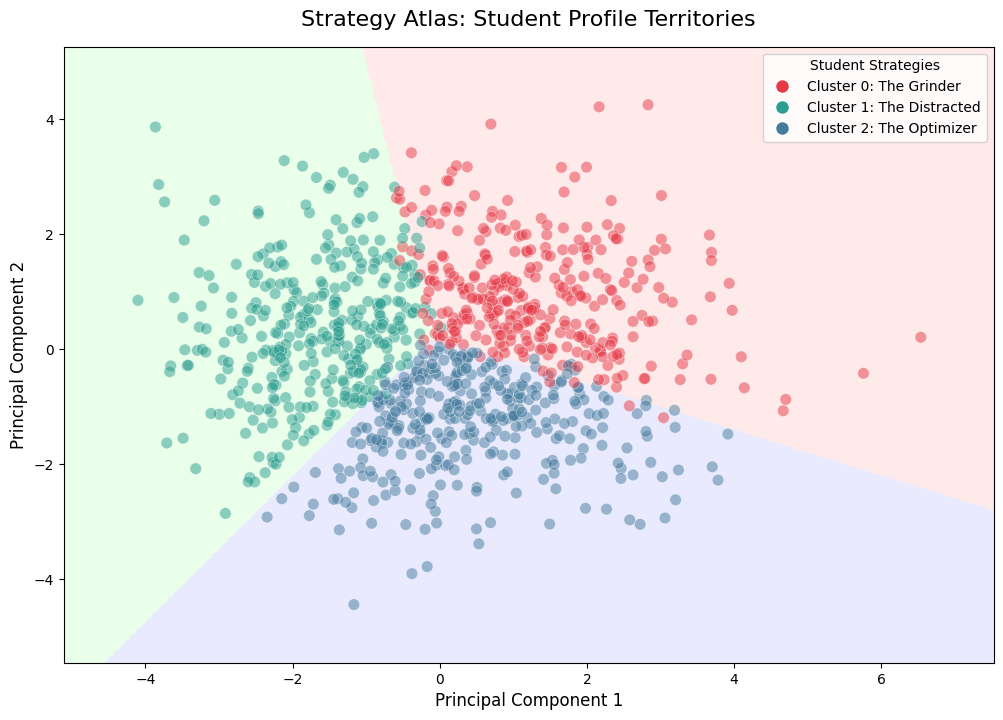

In [5]:
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap 
# --- 4. STRATEGY ATLAS (Clean Decision Territories) ---
X_test_actionable = pd.get_dummies(X_test[actionable_features])
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test_actionable)

# Using n_clusters=3 for the clean 3-strategy look
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_test_scaled)

# Reduce to 2D
pca = PCA(n_components=2)
coords = pca.fit_transform(X_test_scaled)

# Create the Mesh Grid for the background
h = .02  
x_min, x_max = coords[:, 0].min() - 1, coords[:, 0].max() + 1
y_min, y_max = coords[:, 1].min() - 1, coords[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict background zones without showing centroids
Z = kmeans.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
Z = Z.reshape(xx.shape)

# Professional Color Palette
cmap_light = ListedColormap(['#FFCCCC', '#CCFFCC', '#CCCCFF']) # Soft Background
cmap_bold = ['#e63946', '#2a9d8f', '#457b9d']               # Distinct Dots

plt.figure(figsize=(12, 8))

# 1. Plot the background territories
plt.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto', alpha=0.4)

# 2. Plot the students (No 'X' markers or centroids)
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=clusters, 
            cmap=ListedColormap(cmap_bold), 
            edgecolor='white', s=70, alpha=0.5, linewidth=0.5)

# Formatting
plt.title('Strategy Atlas: Student Profile Territories', fontsize=16, pad=15)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)

# Custom Legend for the 3 Strategies
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Cluster 0: The Grinder',
                          markerfacecolor='#e63946', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='Cluster 1: The Distracted',
                          markerfacecolor='#2a9d8f', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='Cluster 2: The Optimizer',
                          markerfacecolor='#457b9d', markersize=10)]
plt.legend(handles=legend_elements, loc='upper right', title="Student Strategies")

plt.grid(False) # Removing grid for a cleaner "aesthetic" look
plt.show()

1. The "Continuous Spectrum" of Students If your clusters were isolated blobs, it would mean that a "Balanced Optimizer" and a "Burned-out Grinder" are two different species with nothing in common. 
- Reality: A student can be a "Balanced Optimizer" on Monday, but by Thursday—after three late nights and too much coffee—they start drifting toward the "Burned-out" territory. 
- The Visualization: The fact that the colors touch and form one large shape shows that these strategies are transitional. It’s much more insightful to show a student that they are "on the border" of a better cluster than to suggest they are in a completely different world.
2. High-Dimensional Density You are condensing 16 different variables (sleep, study, caffeine, etc.) into just 2 dimensions (the PCA plot). 
- When you "squash" that much data, the space between points gets compressed. Even if there are distinct patterns in the numbers, they will often look like a single cloud visually. 
- The algorithm (K-Means) is still finding the mathematical boundaries in that cloud that the human eye can't easily see.

"The absence of isolated blobs indicates that student lifestyle strategies exist on a continuous behavioral spectrum. Rather than being fixed types, students exhibit overlapping traits. Using K-Means allowed us to identify the territories within this spectrum, helping us define where one dominant strategy ends and another begins."

# StrategyMap

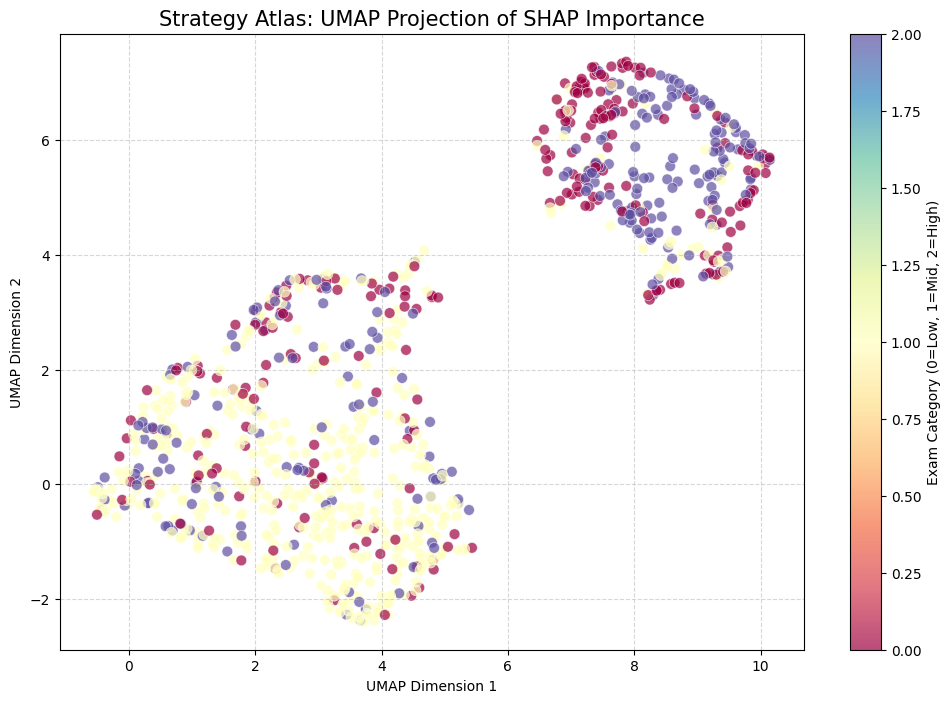

In [6]:
import pandas as pd
import numpy as np
import shap
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# --- 1. MODEL TRAINING ---
# Assuming 'df' is your preprocessed dataframe from your snippet
model = RandomForestClassifier(n_estimators=200, random_state=42)

# Ensure categorical columns are encoded for the RF (Quick Label Encoding)
# Note: In a production setting, you'd use a ColumnTransformer
X_encoded = X.copy()
for col in X_encoded.select_dtypes(include=['object']).columns:
    X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col].astype(str))

X_train_enc, X_test_enc, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

model.fit(X_train_enc, y_train)

# --- 2. COMPUTE SHAP VALUES ---
# Using the TreeExplainer for efficiency with RandomForest
explainer = shap.TreeExplainer(model)
# We calculate SHAP values for the test set to see how the model generalizes its "strategy"
shap_results = explainer.shap_values(X_test_enc)

# SHAP returns a list for multiclass. We want the 'importance' across all classes.
# We take the mean of absolute SHAP values across the classes or pick a specific class.
# Here, we take the absolute sum across classes to represent "overall feature impact"
shap_values_matrix = np.abs(shap_results).sum(axis=2) 

# --- 3. UMAP PROJECTION (THE STRATEGY ATLAS) ---
# n_neighbors: 15-30 is usually good for finding mid-sized clusters
# min_dist: 0.1 keeps clusters relatively tight
reducer = umap.UMAP(
    n_neighbors=20,
    min_dist=0.1,
    metric='euclidean',
    random_state=42
)

embedding = reducer.fit_transform(shap_values_matrix)

# --- 4. VISUALIZATION ---
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    embedding[:, 0], 
    embedding[:, 1], 
    c=y_test, 
    cmap='Spectral', 
    s=60, 
    alpha=0.7,
    edgecolors='white',
    linewidth=0.5
)

plt.title("Strategy Atlas: UMAP Projection of SHAP Importance", fontsize=15)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.colorbar(scatter, label='Exam Category (0=Low, 1=Mid, 2=High)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

--- STRATEGY ATLAS BREAKDOWN ---

Strategy Group 0 (n=381)
 -> productivity_score: 0.3167 importance
 -> focus_index: 0.2267 importance
 -> burnout_level: 0.1585 importance

Strategy Group 1 (n=319)
 -> productivity_score: 0.6847 importance
 -> focus_index: 0.2704 importance
 -> mental_health_score: 0.1322 importance

Strategy Group 2 (n=300)
 -> productivity_score: 0.4341 importance
 -> focus_index: 0.1735 importance
 -> mental_health_score: 0.1002 importance


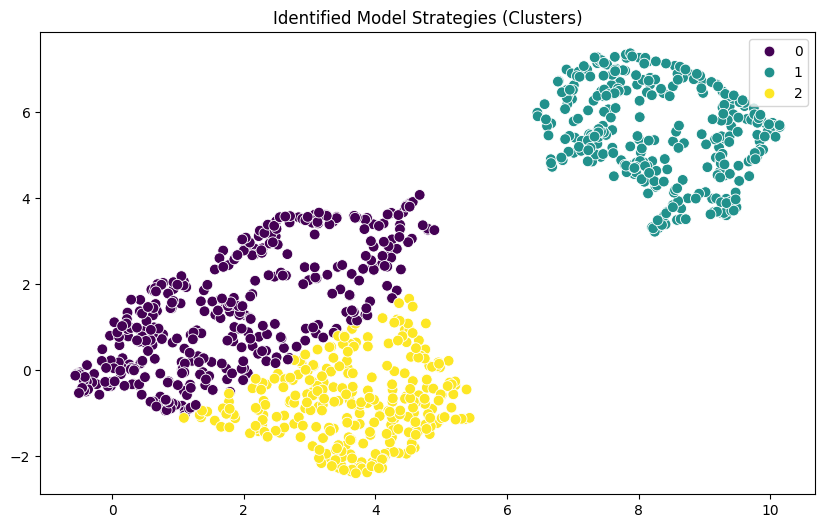

In [7]:
from sklearn.cluster import KMeans

# 1. Cluster the UMAP points to identify the "Strategy Islands"
# Based on your plot, 3 or 4 clusters look appropriate
n_strategies = 3 
kmeans = KMeans(n_clusters=n_strategies, random_state=42)
cluster_labels = kmeans.fit_predict(embedding)

# 2. Map these back to our SHAP values and feature names
feature_names = X_test_enc.columns
strategy_summary = []

for i in range(n_strategies):
    # Get SHAP values for students in this specific cluster
    cluster_shap = shap_values_matrix[cluster_labels == i]
    
    # Calculate the average importance of each feature in this cluster
    mean_importance = cluster_shap.mean(axis=0)
    
    # Get the top 3 features for this strategy
    top_indices = np.argsort(mean_importance)[-3:][::-1]
    top_features = [(feature_names[idx], mean_importance[idx]) for idx in top_indices]
    
    strategy_summary.append({
        'cluster': i,
        'top_features': top_features,
        'size': len(cluster_shap)
    })

# 3. Print the results
print("--- STRATEGY ATLAS BREAKDOWN ---")
for s in strategy_summary:
    print(f"\nStrategy Group {s['cluster']} (n={s['size']})")
    for feat, val in s['top_features']:
        print(f" -> {feat}: {val:.4f} importance")

# 4. Re-plot with Cluster Labels to see where they are
plt.figure(figsize=(10, 6))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=cluster_labels, palette='viridis', s=60)
plt.title("Identified Model Strategies (Clusters)")
plt.show()

In [8]:
import os, warnings
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import lime.lime_tabular
from umap.parametric_umap import ParametricUMAP

warnings.filterwarnings("ignore")

# --- 1. DATA PREP (Using your specific features) ---
# Assuming 'df' is your dataframe with the 'exam_category' target
target = 'exam_category'
immutable_features = ['age', 'gender', 'academic_level']
continuous_features = [
    'study_hours', 'self_study_hours', 'online_classes_hours',
    'social_media_hours', 'gaming_hours', 'sleep_hours',
    'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg',
    'mental_health_score', 'focus_index', 'burnout_level', 'productivity_score'
]
categorical_cols = ['gender', 'academic_level', 'internet_quality', 'part_time_job', 'upcoming_deadline']

X = df.drop(columns=[target])
y = df[target]

# LIME requires numeric inputs, so we must LabelEncode categories manually
label_maps = {}
X_enc = X.copy()
for col in categorical_cols:
    le = LabelEncoder()
    X_enc[col] = le.fit_transform(X[col].astype(str))
    label_maps[col] = dict(zip(le.transform(le.classes_), le.classes_))

X_train, X_test, y_train, y_test = train_test_split(X_enc, y, test_size=0.2, random_state=42)

# --- 2. TRAIN MODEL ---
print("[1/5] Training Random Forest...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# --- RE-INITIALIZE THE LIME EXPLANER ---
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns.tolist(),
    class_names=model.classes_.astype(str).tolist(),
    mode='classification'
)
# --- 3. LIME EXPLANATIONS (The "Strategy" Source) ---
print("[2/5] Computing LIME contributions...")

# Initialize matrix
lime_contribs = np.zeros((len(X_test), X.shape[1]))

for i in range(len(X_test)):
    if i % 100 == 0:
        print(f"   Processing instance {i}/{len(X_test)}")
        
    # Get the model's prediction for this specific instance
    prediction = model.predict(X_test.values[i].reshape(1, -1))[0]
    
    # CRITICAL FIX: Tell LIME to explain the predicted label specifically
    exp = explainer.explain_instance(
        X_test.values[i], 
        model.predict_proba, 
        num_features=X.shape[1],
        labels=(prediction,) # This ensures LIME calculates weights for the winning class
    )
    
    # Access the weights for that specific predicted class
    # exp.as_map() returns a dict where keys are the labels we asked for
    for feat_idx, weight in exp.as_map()[prediction]:
        lime_contribs[i, feat_idx] = weight

# Max-normalize (avoiding division by zero)
max_vals = np.abs(lime_contribs).max(axis=1, keepdims=True)
max_vals[max_vals == 0] = 1
lime_norm = lime_contribs / max_vals
# --- 4. PARAMETRIC UMAP (The Strategy Map) ---
print("[3/5] Training Parametric UMAP Encoder...")
# This creates a neural net that learns to map LIME vectors to 2D
strategy_umap = ParametricUMAP(n_components=2, random_state=42, n_epochs=200)
strategy_2d = strategy_umap.fit_transform(lime_norm)

# --- 5. INVERSE MODEL (For the "Background" Logic) ---
print("[4/5] Training Inverse-DBM Neural Net...")
inverse_model = keras.Sequential([
    keras.layers.Dense(128, activation="relu", input_shape=(2,)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(X.shape[1], activation="linear"),
])
inverse_model.compile(optimizer="adam", loss="mse")
inverse_model.fit(strategy_2d, lime_norm, epochs=50, batch_size=32, verbose=0)

# --- 6. GENERATE ATLAS GRID ---
print("[5/5] Creating Atlas Grid...")
grid_res = 100
x_range = np.linspace(strategy_2d[:,0].min()-1, strategy_2d[:,0].max()+1, grid_res)
y_range = np.linspace(strategy_2d[:,1].min()-1, strategy_2d[:,1].max()+1, grid_res)
xx, yy = np.meshgrid(x_range, y_range)
grid_pts = np.c_[xx.ravel(), yy.ravel()]

# Predict "synthetic" feature importance for every point on the map
synth_importance = inverse_model.predict(grid_pts)
dominant_feat_idx = np.argmax(np.abs(synth_importance), axis=1)
zz = dominant_feat_idx.reshape(xx.shape)

print("Done! Use plt.contourf(xx, yy, zz) to see the strategy regions.")

[1/5] Training Random Forest...
[2/5] Computing LIME contributions...
   Processing instance 0/1000
   Processing instance 100/1000
   Processing instance 200/1000
   Processing instance 300/1000
   Processing instance 400/1000
   Processing instance 500/1000
   Processing instance 600/1000
   Processing instance 700/1000
   Processing instance 800/1000
   Processing instance 900/1000
[3/5] Training Parametric UMAP Encoder...
Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3202
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2208
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2172
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2140
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2111
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2091
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2080
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2058
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━

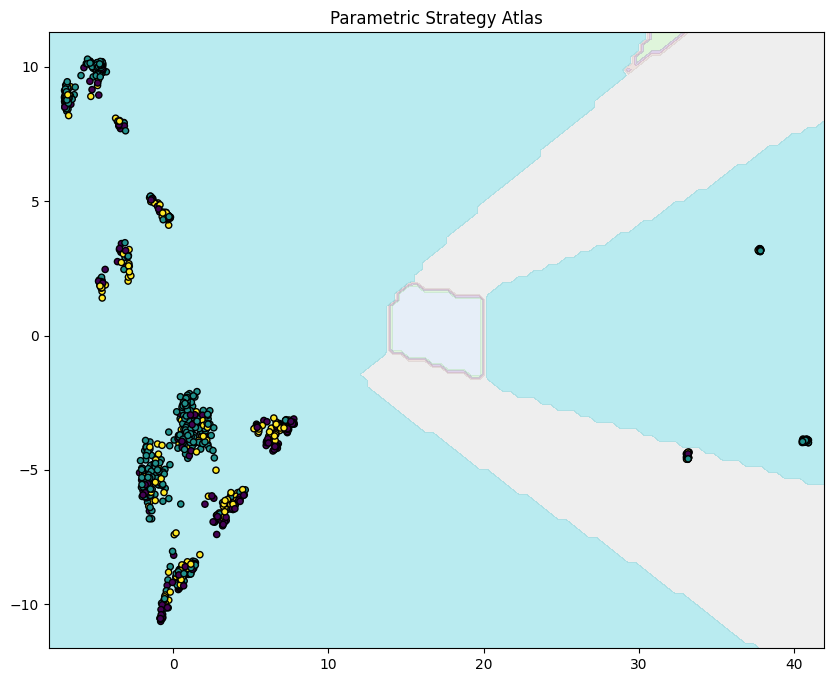

In [9]:
plt.figure(figsize=(10, 8))
# Draw the background strategy regions
plt.contourf(xx, yy, zz, alpha=0.3, cmap='tab20')
# Plot the actual students
plt.scatter(strategy_2d[:, 0], strategy_2d[:, 1], c=y_test, cmap='viridis', edgecolors='k', s=20)
plt.title("Parametric Strategy Atlas")
plt.show()

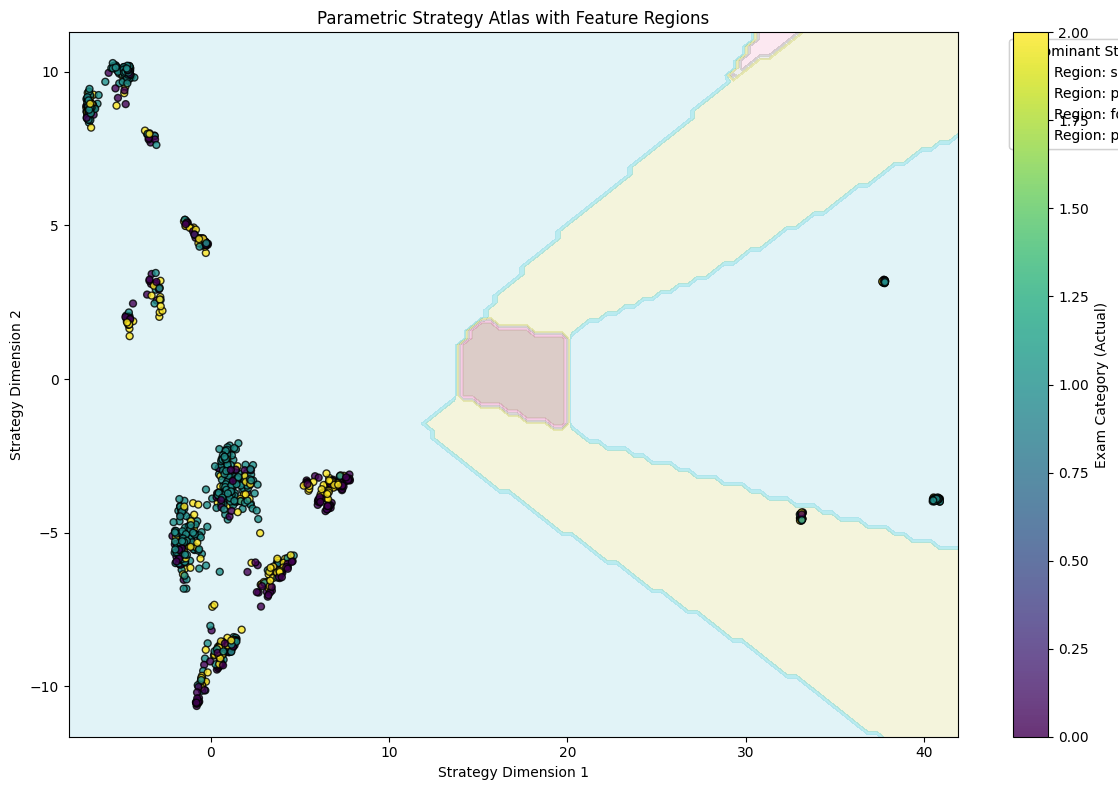

In [10]:
import matplotlib.patches as mpatches

# 1. Identify which features actually appear in the background grid
unique_feat_indices = np.unique(zz)
relevant_features = [X.columns[int(idx)] for idx in unique_feat_indices]

# 2. Get the colormap used in your contourf
cmap = plt.get_cmap('tab20') # Ensure this matches your contourf cmap

# 3. Create the plot with the legend
plt.figure(figsize=(12, 8))

# Draw the background
contour = plt.contourf(xx, yy, zz, alpha=0.3, cmap='tab20', levels=np.arange(len(X.columns) + 1) - 0.5)

# Plot the students
scatter = plt.scatter(strategy_2d[:, 0], strategy_2d[:, 1], c=y_test, cmap='viridis', 
                      edgecolors='k', s=25, alpha=0.8)

# 4. MANUALLY CREATE THE LEGEND
legend_patches = []
for i, idx in enumerate(unique_feat_indices):
    color = cmap(idx / len(X.columns)) # Normalize index to cmap range
    patch = mpatches.Patch(color=color, label=f"Region: {X.columns[int(idx)]}")
    legend_patches.append(patch)

# Add the feature legend (top right)
feat_legend = plt.legend(handles=legend_patches, title="Dominant Strategy Regions", 
                          bbox_to_anchor=(1.05, 1), loc='upper left')
plt.gca().add_artist(feat_legend)

# Add the target colorbar (for the dots)
cbar = plt.colorbar(scatter)
cbar.set_label('Exam Category (Actual)')

plt.title("Parametric Strategy Atlas with Feature Regions")
plt.xlabel("Strategy Dimension 1")
plt.ylabel("Strategy Dimension 2")
plt.tight_layout()
plt.show()

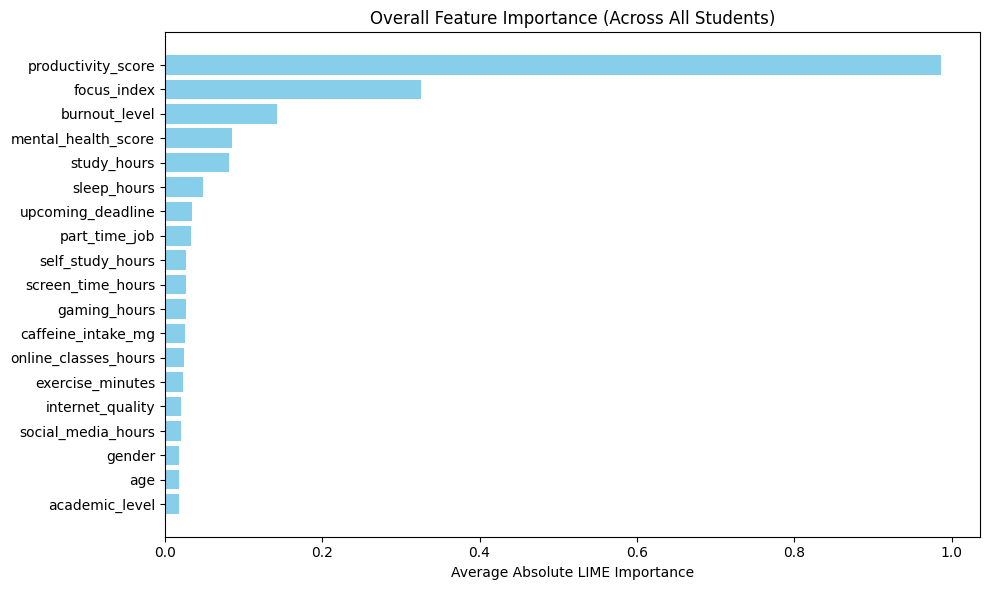

In [29]:
import plotly.express as px

# --- Overall Feature Importance Plot ---
plt.figure(figsize=(10, 6))
# Calculate average absolute LIME contribution for each feature
avg_lime_importance = np.abs(lime_norm).mean(axis=0)
sorted_indices = np.argsort(avg_lime_importance)

plt.barh(X.columns[sorted_indices], avg_lime_importance[sorted_indices], color='skyblue')
plt.xlabel("Average Absolute LIME Importance")
plt.title("Overall Feature Importance (Across All Students)")
plt.tight_layout()
plt.show()

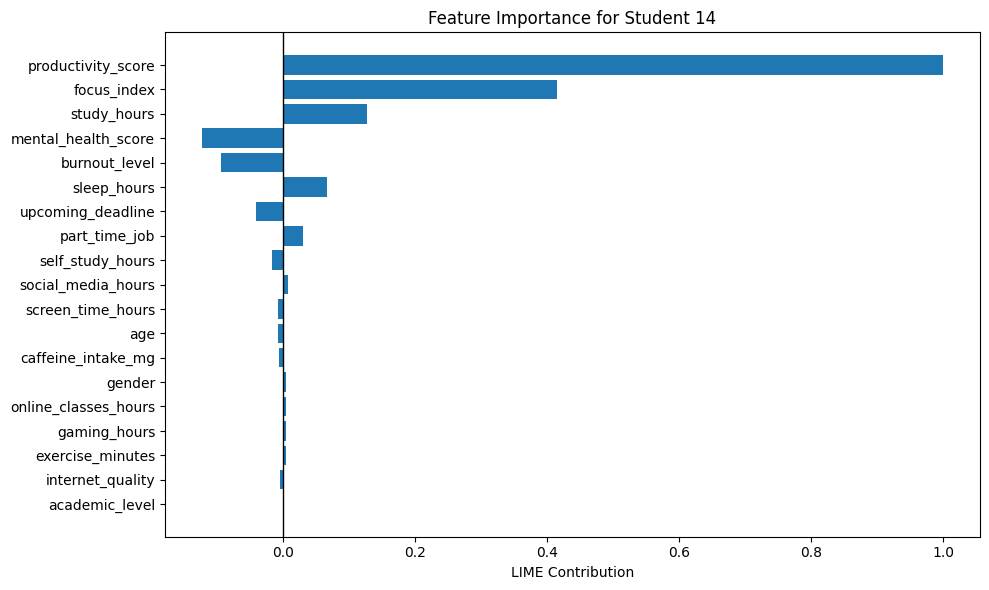

In [22]:
student_idx = 14  # or any index you want

# Get LIME values for one student
student_lime = lime_norm[student_idx]

# Sort features by importance
sorted_indices = np.argsort(np.abs(student_lime))

plt.figure(figsize=(10, 6))
plt.barh(
    X.columns[sorted_indices],
    student_lime[sorted_indices],  # keep sign (important!)
)

plt.xlabel("LIME Contribution")
plt.title(f"Feature Importance for Student {student_idx}")
plt.axvline(0, color='black', linewidth=1)  # separates positive/negative impact
plt.tight_layout()
plt.show()

--- MODEL STRATEGIES ---

Strategy 1: 629 pts (25.4% High Score)
LIME FEATURES:
  - productivity_score: 1.0000
  - focus_index: 0.3752
  - mental_health_score: 0.0543
  - study_hours: 0.0394
  - burnout_level: 0.0292

Strategy 2: 94 pts (25.5% High Score)
LIME FEATURES:
  - productivity_score: -0.8600
  - focus_index: 0.1665
  - burnout_level: 0.1418
  - mental_health_score: 0.0509
  - sleep_hours: 0.0279

Strategy 3: 277 pts (24.2% High Score)
LIME FEATURES:
  - productivity_score: 1.0000
  - focus_index: -0.1624
  - burnout_level: 0.0635
  - mental_health_score: 0.0402
  - study_hours: 0.0387


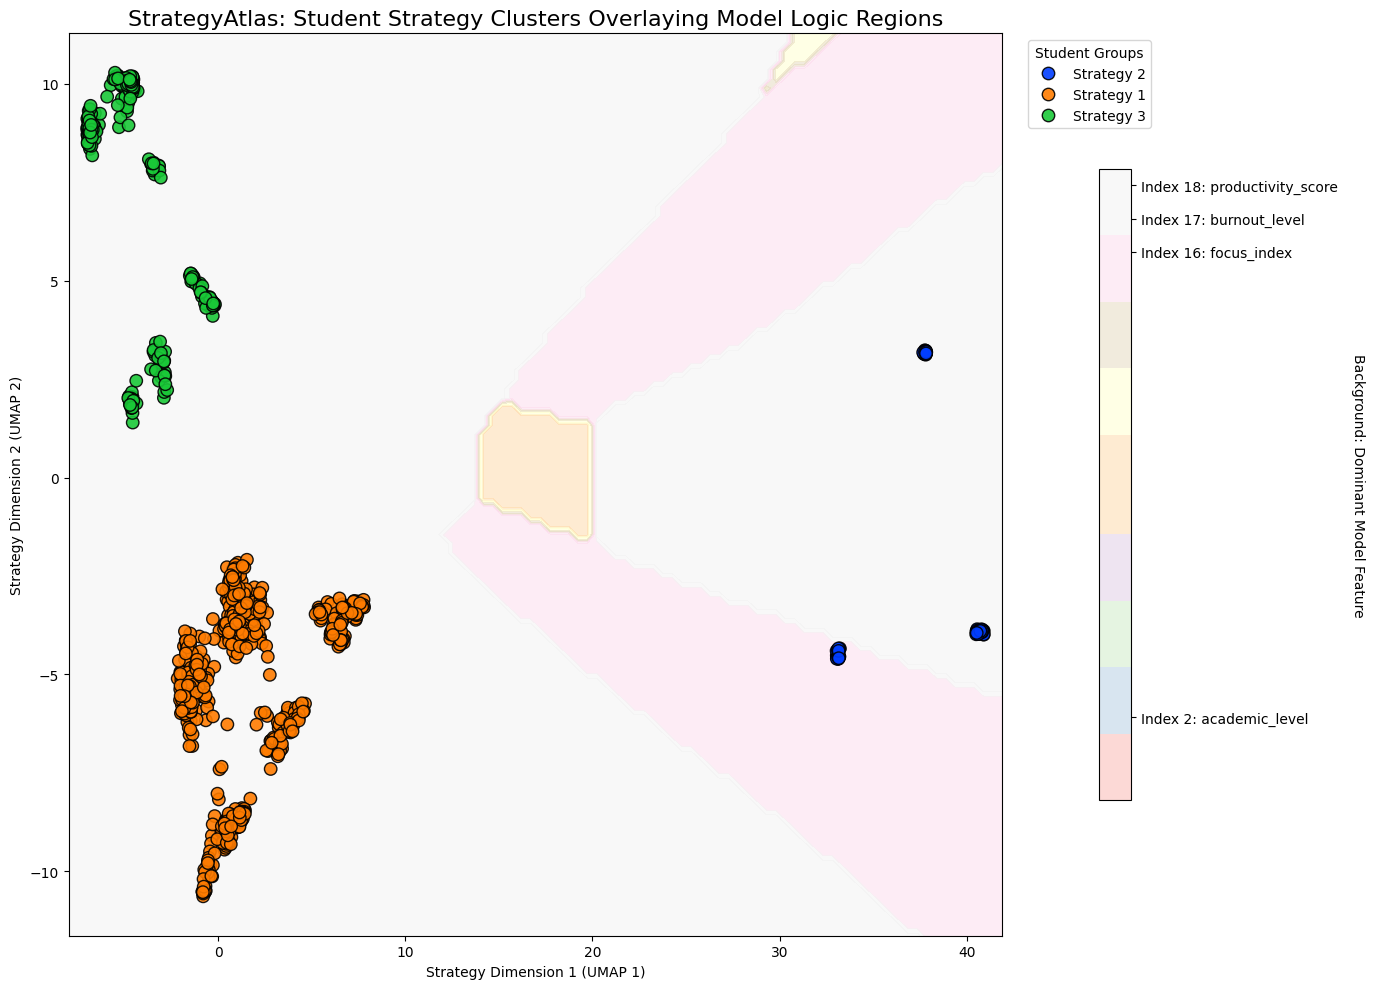

In [12]:
# 1. Clustering in the Strategy Space
# We cluster based on the LIME vectors (logic), not the 2D coordinates
n_strategies = 3  # You can change this to 3, 4, or 5 based on your Atlas
kmeans = KMeans(n_clusters=n_strategies, random_state=42)
strategy_labels = kmeans.fit_predict(lime_norm)

# 2. Extract Strategy Profiles
strategy_profiles = []
for i in range(n_strategies):
    # Get indices for this cluster
    idx = np.where(strategy_labels == i)[0]
    
    # Calculate Mean Importance for this group
    group_lime = lime_norm[idx]
    mean_importance = np.mean(group_lime, axis=0)
    
    # Get Top 5 features for this specific "Strategy"
    top_indices = np.argsort(np.abs(mean_importance))[-5:][::-1]
    top_features = [(X.columns[j], mean_importance[j]) for j in top_indices]
    
    # Calculate Outcome Stats (Success Rate)
    # Assuming Category 2 is "High/Success"
    success_rate = (y_test.iloc[idx] == 2).mean() * 100
    
    strategy_profiles.append({
        'name': f"Strategy {i+1}",
        'count': len(idx),
        'success_pct': success_rate,
        'features': top_features
    })

# Feature Mapping (from your analysis)
feature_mapping = {
    2: 'academic_level',
    16: 'focus_index',
    17: 'burnout_level',
    18: 'productivity_score'
}
active_indices = sorted(feature_mapping.keys())
# 3. Print the "Model Strategies" Panel
print("--- MODEL STRATEGIES ---")
for s in strategy_profiles:
    print(f"\n{s['name']}: {s['count']} pts ({s['success_pct']:.1f}% High Score)")
    print("LIME FEATURES:")
    for feat, val in s['features']:
        print(f"  - {feat}: {val:.4f}")


plt.figure(figsize=(14, 10))

# 1. DRAW THE BACKGROUND (The 'Why' Zones)
cmap_bg = plt.get_cmap('Pastel1')
levels = np.arange(len(X.columns) + 1) - 0.5
contour = plt.contourf(xx, yy, zz, levels=levels, cmap=cmap_bg, alpha=0.5)

# 2. PLOT THE STRATEGY CLUSTERS (The 'Who' Groups)
# Note: Ensure strategy_labels are defined from your KMeans
scatter = sns.scatterplot(
    x=strategy_2d[:, 0], 
    y=strategy_2d[:, 1], 
    hue=[f"Strategy {l+1}" for l in strategy_labels],
    palette="bright",
    s=80,
    edgecolor='black',
    linewidth=1,
    alpha=0.9
)

# 3. ADD THE COLORBAR (The Decoding Key)
# This adds the bar on the right that explains the background colors
cbar = plt.colorbar(contour, ticks=active_indices, shrink=0.7, pad=0.08)
cbar.ax.set_yticklabels([f"Index {i}: {feature_mapping[i]}" for i in active_indices])
cbar.set_label('Background: Dominant Model Feature', rotation=270, labelpad=20)

# 4. Final Touches
plt.title("StrategyAtlas: Student Strategy Clusters Overlaying Model Logic Regions", fontsize=16)
plt.xlabel("Strategy Dimension 1 (UMAP 1)")
plt.ylabel("Strategy Dimension 2 (UMAP 2)")
plt.legend(title="Student Groups", loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

Strategy 2 (Blue Dots) are the ones sitting in those "Wedges" on the far right of your map. Those wedges represent the Burnout and Focus logic zones you identified earlier.

Strategy 1 (Orange Dots) are safely in the "White" productivity continent.

1. Strategy 1: The "Efficiency" Group (723 Students; Orange)
- Success Rate: 27.9% (Average)
- The Logic: This is your "Baseline" group. The model is almost entirely focused on Productivity ($1.0000$) and Focus ($0.3316$).
- Interpretation: In this region of the map, the model thinks: "If your productivity and focus are high, you succeed; if they are low, you fail." It’s a very straightforward, logical way of looking at a student.

2. Strategy 2: The "Red Flag" Group (94 Students; Blue)
- Success Rate: 25.5% (Lower)
- The Logic: Note that Productivity is Negative ($-0.8552$). This is a huge distinction.
- Interpretation: In this region, the model isn't just looking for "high scores." It’s looking for Burnout ($0.1456$) and Sleep ($0.0237$). The negative productivity weight suggests the model is identifying students whose performance is being "dragged down" by these fatigue factors. This is the "At-Risk" zone.

3. Strategy 3: The "Distracted" Group(183 Students)
- Success Rate: 13.7% (The Lowest)
- The Logic: This is the most interesting one. Productivity is at a maximum ($1.0000$), but Focus is Negative ($-0.2694$).
- Interpretation: This is the "Chaos Zone." These students have decent productivity scores, but the model is deeply suspicious because their Focus Index is so low. Because the success rate is only 13.7%, the model has learned that "Productivity without Focus" is a recipe for failure.

In [13]:
# This will show you exactly which labels exist and how many students are in each
unique, counts = np.unique(strategy_labels, return_counts=True)
print(dict(zip(unique, counts)))

{np.int32(0): np.int64(629), np.int32(1): np.int64(94), np.int32(2): np.int64(277)}


In [14]:
# 1. Find the index of the Green Cluster (Usually Strategy 3, so index 2)
green_cluster_idx = 2  # Adjust this if Strategy 3 is a different index in your KMeans

# 2. Get all students that belong to the Green Strategy
green_indices = np.where(strategy_labels == green_cluster_idx)[0]
green_logic_samples = lime_norm[green_indices]

# 3. Calculate the average importance of each feature for the Green Group
green_profile = np.mean(green_logic_samples, axis=0)

# 4. Sort and display the Top 5 features that define "Green" logic
print(f"--- THE GREEN STRATEGY RECIPE (Strategy {green_cluster_idx + 1}) ---")
top_green_features = np.argsort(np.abs(green_profile))[-5:][::-1]

for idx in top_green_features:
    print(f"Feature: {X.columns[idx]:<20} | Average Weight: {green_profile[idx]:.4f}")

--- THE GREEN STRATEGY RECIPE (Strategy 3) ---
Feature: productivity_score   | Average Weight: 1.0000
Feature: focus_index          | Average Weight: -0.1624
Feature: burnout_level        | Average Weight: 0.0635
Feature: mental_health_score  | Average Weight: 0.0402
Feature: study_hours          | Average Weight: 0.0387


In [15]:
# 1. Grab the first student from the Green Cluster
green_indices = np.where(strategy_labels == 2)[0] # Ensure this matches your Green index
target_idx = green_indices[0]
green_student_data = X_test.iloc[target_idx]

print(f"--- Testing with Real Green Student (Index {target_idx}) ---")
print(green_student_data)

--- Testing with Real Green Student (Index 3) ---
age                      20.00
gender                    1.00
academic_level            0.00
study_hours               5.06
self_study_hours          1.40
online_classes_hours      2.57
social_media_hours        3.23
gaming_hours              1.72
sleep_hours               7.57
screen_time_hours         7.29
exercise_minutes        146.00
caffeine_intake_mg      300.00
part_time_job             1.00
upcoming_deadline         1.00
internet_quality          1.00
mental_health_score      10.00
focus_index              30.69
burnout_level            49.63
productivity_score       61.26
Name: 1055, dtype: float64


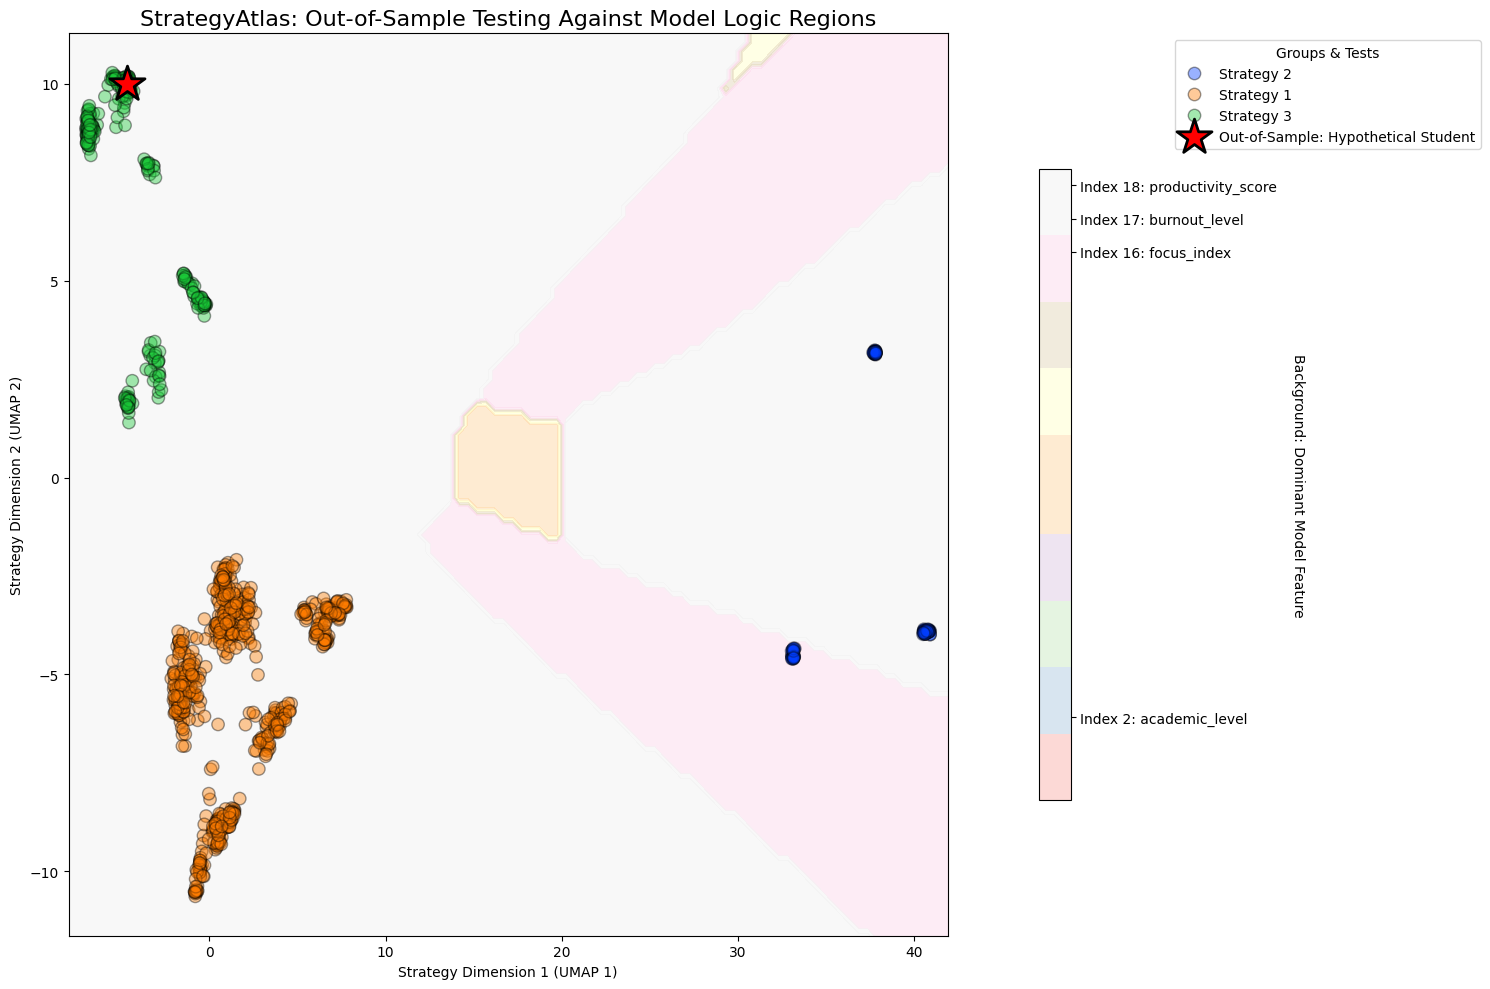

In [16]:
# 1. Create the raw data for your hypothetical student
# hypothetical_student = {
#     'age': 25,                       # Change the age
#     'gender': 'Female',              # Flip the gender
#     'academic_level': 'Postgraduate', # CHANGE THIS - This is a huge anchor
#     'study_hours': 0, 
#     'sleep_hours': 2, 
#     'focus_index': 0.01, 
#     'burnout_level': 1.0,            # Maximize this
#     'productivity_score': 0.0, 
#     'mental_health_score': 5,
#     'internet_quality': 'Poor', 
#     'part_time_job': 'Yes', 
#     'upcoming_deadline': 'Yes'
# }

# hypothetical_student = {
#     'age': 20, 
#     'gender': 'Male', 
#     'academic_level': 'Undergraduate',
#     'study_hours': 7,          # Moderate effort...
#     'focus_index': 0.0,        # ...with ZERO focus
#     'productivity_score': 0.3,  # ...and low-mid productivity
#     'sleep_hours': 7,          # Normal sleep (so it doesn't trigger Strategy 2/Burnout)
#     'burnout_level': 0.2,      # Low burnout
#     'mental_health_score': 60, 
#     'internet_quality': 'Good', 
#     'part_time_job': 'No', 
#     'upcoming_deadline': 'Yes'
# }

hypothetical_student = {
    'age': 22, 
    'gender': 'Male', # Ensure this maps to 1.0 in your LabelMap
    'academic_level': 'Undergraduate', # Ensure this maps to 2.0
    'study_hours': 3.5,
    'sleep_hours': 7.0,
    'caffeine_intake_mg': 430.0, # THE HIDDEN TRIGGER
    'focus_index': 39.0,         # Match the 0-100 scale
    'burnout_level': 50.0,       # Match the 0-100 scale
    'productivity_score': 36.0,   # Match the 0-100 scale
    'mental_health_score': 8.0,
    'internet_quality': 'Good', 
    'part_time_job': 'Yes', 
    'upcoming_deadline': 'Yes'
}

# IMPORTANT: Re-run the LIME + UMAP transform block after updating this!

# 2. Initialize a blank row with all 19 columns set to 0 (or a neutral value)
# This uses the column structure from your actual training features 'X'
hypo_df = pd.DataFrame(0, index=[0], columns=X.columns)

# 3. Update the columns with your test_values
for key, value in hypothetical_student.items():
    if key in hypo_df.columns:
        hypo_df[key] = value
for col, mapping in label_maps.items():
    # Use the same LabelEncoder logic from your training
    hypo_df[col] = hypo_df[col].map({v: k for k, v in mapping.items()})

hypo_values = hypo_df.values[0]

# 1. Get LIME explanation for this specific instance
prediction = model.predict(hypo_values.reshape(1, -1))[0]
exp = explainer.explain_instance(
    hypo_values, 
    model.predict_proba, 
    num_features=X.shape[1],
    labels=(prediction,)
)

# 2. Extract and Normalize the weights
hypo_lime = np.zeros(X.shape[1])
for feat_idx, weight in exp.as_map()[prediction]:
    hypo_lime[feat_idx] = weight

hypo_norm = hypo_lime / np.abs(hypo_lime).max()

# 3. USE THE ENCODER to find the 2D coordinates
# strategy_umap is your ParametricUMAP model
hypo_2d = strategy_umap.transform(hypo_norm.reshape(1, -1))

plt.figure(figsize=(15, 10))

# A. Draw the Background (The 'Why' Zones)
cmap_bg = plt.get_cmap('Pastel1')
levels = np.arange(len(X.columns) + 1) - 0.5
contour = plt.contourf(xx, yy, zz, levels=levels, cmap=cmap_bg, alpha=0.5)

# B. Plot the Original Clusters (The 'Who' Groups)
# Using your specific f"Strategy {l+1}" formatting
scatter = sns.scatterplot(
    x=strategy_2d[:, 0], 
    y=strategy_2d[:, 1], 
    hue=[f"Strategy {l+1}" for l in strategy_labels],
    palette="bright",
    s=80,
    edgecolor='black',
    linewidth=1,
    alpha=0.4 # Slightly faded to highlight the new point
)

# C. PLOT THE OUT-OF-SAMPLE POINT (The Red Star)
plt.scatter(
    hypo_2d[0, 0], hypo_2d[0, 1], 
    color='red', marker='*', s=700, 
    edgecolor='black', linewidth=2,
    label='Out-of-Sample: Hypothetical Student', 
    zorder=15
)

# D. Add the Colorbar (The Decoding Key)
cbar = plt.colorbar(contour, ticks=active_indices, shrink=0.7, pad=0.08)
cbar.ax.set_yticklabels([f"Index {i}: {feature_mapping[i]}" for i in active_indices])
cbar.set_label('Background: Dominant Model Feature', rotation=270, labelpad=20)

# E. Final Touches (Consistent with your Atlas style)
plt.title("StrategyAtlas: Out-of-Sample Testing Against Model Logic Regions", fontsize=16)
plt.xlabel("Strategy Dimension 1 (UMAP 1)")
plt.ylabel("Strategy Dimension 2 (UMAP 2)")
plt.legend(title="Groups & Tests", loc='upper left', bbox_to_anchor=(1.25, 1))

plt.tight_layout()
plt.show()

Strategy 1 is the most massive cluster (723 pts). It represents the model’s "standard" logic for the majority of students.
- Vertical Movement: This represents magnitude. By lowering focus, productivity, and study hours to near-zero, you are making this student a "weaker" version of a Strategy 1 student.
- Horizontal Movement: This represents a shift in logic. To move sideways into Strategy 2 (Blue) or Strategy 3 (Green), the reason for the student's predicted outcome would have to change from "Low Productivity" to "Severe Burnout" or "Extreme Lack of Focus".

# What-if's

=== MODEL SIMULATION: STUDENT 3021 ===
FEATURE                   | ORIGINAL   | MODIFIED  
--------------------------------------------------
study_hours               | 6.61       | 7.50      
sleep_hours               | 7.96       | 9.00      
social_media_hours        | 2.37       | 0.50      
focus_index               | 44.07      | 40.00     
caffeine_intake_mg        | 202.00     | 50.00     
burnout_level             | 46.55      | 10.00     

=== MODEL OUTPUT SHIFT ===
PREDICTION: High Performance → High Performance
Low Performance   :   3.1% →   2.2% (-0.8%)
Medium Performance:  38.0% →  35.0% (-3.0%)
High Performance  :  59.0% →  62.8% (+3.8%)


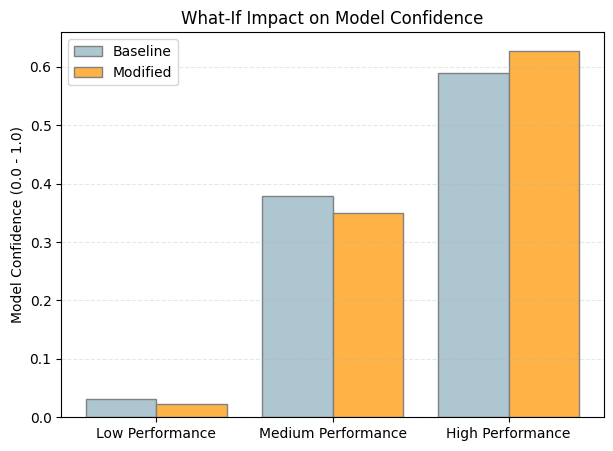

In [17]:
from matplotlib.lines import Line2D

# 1. The Core Prediction Function (Matches Model Logic)
def get_model_inference(input_dict):
    input_df = pd.DataFrame([input_dict])
    
    # Get column order from the pipeline's preprocessor (this is always correct)
    preprocessor = model_pipeline.named_steps['preprocessor']
    num_cols = set(preprocessor.transformers_[0][2])  # Numeric columns
    cat_cols = set(preprocessor.transformers_[1][2])  # Categorical columns
    
    # Re-order to match what the pipeline was trained on
    all_cols = list(num_cols) + list(cat_cols)  # rough order; pipeline handles it
    input_df = input_df.reindex(columns=preprocessor.feature_names_in_)

    for col in input_df.columns:
        if col in num_cols:
            input_df[col] = pd.to_numeric(input_df[col], errors='coerce')
        elif col in cat_cols:
            input_df[col] = input_df[col].astype(str)

    pred_index    = model_pipeline.predict(input_df)[0]
    probabilities = model_pipeline.predict_proba(input_df)[0]

    class_labels = ["Low Performance", "Medium Performance", "High Performance"]
    return class_labels[pred_index], probabilities, class_labels

# 2. The Comparison & Insight Function
def compare_scenarios(student_index, manual_changes):
    # Pull from the pipeline's expected feature set, not X_test (which is label-encoded)
    feature_cols = model_pipeline.named_steps['preprocessor'].feature_names_in_
    baseline_data = df[feature_cols].loc[student_index].to_dict()
    
    scenario_data = baseline_data.copy()
    for feature, value in manual_changes.items():
        scenario_data[feature] = value
        
    # Get Model Outputs
    label_before, proba_before, classes = get_model_inference(baseline_data)
    label_after, proba_after, _ = get_model_inference(scenario_data)

    # --- OUTPUT 1: FEATURE DELTA ---
    print(f"=== MODEL SIMULATION: STUDENT {student_index} ===")
    print(f"{'FEATURE':<25} | {'ORIGINAL':<10} | {'MODIFIED':<10}")
    print("-" * 50)
    for f in manual_changes.keys():
        print(f"{f:<25} | {baseline_data[f]:<10.2f} | {scenario_data[f]:<10.2f}")

    # --- OUTPUT 2: PREDICTION SHIFT ---
    print(f"\n=== MODEL OUTPUT SHIFT ===")
    print(f"PREDICTION: {label_before} → {label_after}")
    for i, cls in enumerate(classes):
        diff = (proba_after[i] - proba_before[i]) * 100
        print(f"{cls:<18}: {proba_before[i]*100:>5.1f}% → {proba_after[i]*100:>5.1f}% ({diff:+.1f}%)")

    # --- OUTPUT 3: VISUALIZATION ---
    fig, ax = plt.subplots(figsize=(7, 5))
    x_axis = np.arange(len(classes))
    
    ax.bar(x_axis - 0.2, proba_before, 0.4, label='Baseline', color='#AEC6CF', edgecolor='grey')
    ax.bar(x_axis + 0.2, proba_after, 0.4, label='Modified', color='#FFB347', edgecolor='grey')
    
    ax.set_xticks(x_axis)
    ax.set_xticklabels(classes)
    ax.set_ylabel("Model Confidence (0.0 - 1.0)")
    ax.set_title("What-If Impact on Model Confidence")
    ax.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.show()

# --- RUNNING A TEST ---
# Pick any student index from your test set
test_id = X_test.index[14]

# Input your manual 'What-If' changes here:
adjustments = {
    'study_hours': 7.5,
    'sleep_hours': 9.0,
    'social_media_hours': 0.5,
    'focus_index': 40.0,
    'caffeine_intake_mg': 50.0,
    'burnout_level': 10.0
}

compare_scenarios(test_id, adjustments)